## **Analisis Exploratorio**
### **Desigualdad Educativa en Chile:** Análisis de Resultados PAES por Tipo de Establecimiento

#### **Nombres:** Lucas Chicao - Ninoska Cid - Isidora Gomez

#### **Curso**: IMT-2200 - Introduccion a la Ciencias de Datos

___
### **Contexto del proyecto:** 
La PAES es la prueba que miles de estudiantes chilenos rinden para acceder a la universidad, pero es un hecho que no todos cuentan con las mismas oportunidades educativas, ya que estas dependen del tipo de colegio en el que estudiaron.

En este proyecto, nos proponemos investigar si efectivamente hay diferencias en los puntajes de la PAES entre estudiantes de colegios públicos, subvencionados y privados, y también medir la magnitud de esas posibles diferencias.


### **Preguntas a responder:**
-¿Hay diferencias en los puntajes entre colegios públicos, subvencionados y privados?

-¿Qué tipo de colegio tiene mejores resultados en promedio?

-¿Qué tan grande es la brecha entre estos grupos?

-¿Existe correlación entre el tipo de establecimiento y las probabilidades de acceso a universidades tradicionales?

-¿Los resultados confirman las desigualdades educativas documentadas en otros estudios?

-...

### **Datos a usar:**
Los datos que usaremos en nuestro proyecto seran principalmente de base de datos de:

-DEMRE

-chiquillos si les parece aqui hay una base de datos para poder usar, si lo usamos eliminen este mensajito: https://www.kaggle.com/datasets/daniellopez01/admisionuescl

### **Analisis Exploratorio:**
En las siguientes lineas exploraremos los datos que ya obtuvimos y revisaremos como vamos en relacion con datos.
 

In [3]:
#LIBRERIAS A USAR
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
#...

# Analisis Exploratorio de la base de datos del DEMRE (2023 - 2025)

En este JupyterNotebook vamos  a aplicarle EDA a los archivos clasificados como Matricula de 2023 a 2025 de la Base de datos del DEMRE 

## Cargar datos y generar DF

In [ ]:
#CARGAR DATOS Y DF

base_path = os.path.dirname(os.getcwd())  # Esto sube un nivel desde 'Análisis Exploratorio'

file_path_23 = os.path.join(base_path, 'DEMRE_bdd', '2023', 'Rendicion','Rinden_Admisión2023','ArchivoC_Adm2023.csv')
file_path_24 = os.path.join(base_path, 'DEMRE_bdd', '2024', 'Rendicion','Rinden_Admisión2024','ArchivoC_Adm2024.csv')
file_path_25 = os.path.join(base_path, 'DEMRE_bdd', '2025', 'Rendicion','Rinden_Admisión2025','ArchivoC_Adm2025.csv')

df_2023_rendicion = pd.read_csv(file_path_23, sep=';')
df_2024_rendicion = pd.read_csv(file_path_24, sep=';')
df_2025_rendicion = pd.read_csv(file_path_25, sep=';')
# uno todo en un df
df_rendiciones = pd.concat([df_2023_rendicion, df_2024_rendicion, df_2025_rendicion], ignore_index=True)
df_rendiciones

C:\Users\cidni\AppData\Local\Temp\ipykernel_23264\1356383814.py:12: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2024_rendicion = pd.read_csv(file_path_24, sep=';')
C:\Users\cidni\AppData\Local\Temp\ipykernel_23264\1356383814.py:13: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025_rendicion = pd.read_csv(file_path_25, sep=';')


,ID_aux,RBD,COD_ENS,GRUPO_DEPENDENCIA,RAMA_EDUCACIONAL,SITUACION_EGRESO,CODIGO_REGION,CODIGO_COMUNA,PROMEDIO_NOTAS,PORC_SUP_NOTAS,...,MATE1_INV_ACTUAL,MATE2_INV_ACTUAL,MATE2_REG_ANTERIOR,CLEC_INV_ANTERIOR,MATE_INV_ANTERIOR,HCSOC_INV_ANTERIOR,CIEN_INV_ANTERIOR,MODULO_INV_ANTERIOR,MATE1_INV_ANTERIOR,MATE2_INV_ANTERIOR
0,id_0000900170003,10584.0,363.0,3.0,H2,5,13.0,13401.0,"5,03",80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,id_0000900470024,10250.0,363.0,3.0,H2,1,13.0,13107.0,"5,9",30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,id_0000900670068,12667.0,310.0,2.0,H1,5,1.0,1101.0,5,100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,id_0001900070103,7006.0,310.0,2.0,H1,5,14.0,14202.0,"5,6",40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,id_0001900070149,6752.0,610.0,3.0,T3,5,14.0,14101.0,"5,28",70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
911441,id_5995599440825,9986.0,410.0,3.0,T1,1,13.0,13126.0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
911442,id_4895488246247,NaN,NaN,NaN,H4,4,NaN,NaN,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
911443,id_9866988747313,9140.0,310.0,2.0,H1,5,13.0,13122.0,"6,28",10,...,648.0,381.0,393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
911444,id_5866598447255,2733.0,310.0,3.0,H1,5,7.0,7301.0,"5,68",40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Exploración

In [38]:
#EXPLORACION 
print(f'Columnas : {df_rendiciones.columns}')
print('-----------')
print(f'Filas : {df_rendiciones.shape[0]}, Columnas : {df_rendiciones.shape[1]}') #Filas, Columnas
print('-----------\n')
print(df_rendiciones.info())
print('-----------')

Columnas : Index(['ID_aux', 'RBD', 'COD_ENS', 'GRUPO_DEPENDENCIA', 'RAMA_EDUCACIONAL',
       'SITUACION_EGRESO', 'CODIGO_REGION', 'CODIGO_COMUNA', 'PROMEDIO_NOTAS',
       'PORC_SUP_NOTAS', 'PTJE_NEM', 'PTJE_RANKING', 'CLEC_REG_ACTUAL',
       'MATE1_REG_ACTUAL', 'MATE2_REG_ACTUAL', 'HCSOC_REG_ACTUAL',
       'CIEN_REG_ACTUAL', 'MODULO_REG_ACTUAL', 'CLEC_INV_ACTUAL',
       'MATE_INV_ACTUAL', 'HCSOC_INV_ACTUAL', 'CIEN_INV_ACTUAL',
       'MODULO_INV_ACTUAL', 'CLEC_REG_ANTERIOR', 'MATE1_REG_ANTERIOR',
       'HCSOC_REG_ANTERIOR', 'CIEN_REG_ANTERIOR', 'MODULO_REG_ANTERIOR',
       'MATE1_INV_ACTUAL', 'MATE2_INV_ACTUAL', 'MATE2_REG_ANTERIOR',
       'CLEC_INV_ANTERIOR', 'MATE_INV_ANTERIOR', 'HCSOC_INV_ANTERIOR',
       'CIEN_INV_ANTERIOR', 'MODULO_INV_ANTERIOR', 'MATE1_INV_ANTERIOR',
       'MATE2_INV_ANTERIOR'],
      dtype='object')
-----------
Filas : 911446, Columnas : 38
-----------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911446 entries, 0 to 911445
Data columns (total 38

## Limpieza de los datos

In [131]:
#LIMPIEZA DE DATOS

columnas_criticas = ["ID_aux", "PROMEDIO_NOTAS", "PTJE_NEM", "PTJE_RANKING"]
# elijo estas columnas ya que las otras son de las pruebas elegidas y sus puntajes obtenidos
# pero puede existir un caso donde una persona solo se inscribió a 1 prueba y todas las otras pruebas quedarían con NaN
# a diferencia de "ID_aux", ya que si este es NaN, entonces no existe el postulante y no tendría sentido

df_rendicion_notnull = df_rendiciones.dropna(subset=columnas_criticas)

# PROMEDIO DE NOTAS
# las notas no pueden pasar el 7.0 (nota maxima) ni el 1.0 (nota minima)
# convierto los datos a str (solo los de las columnas numericas de columnas criticas)
# para poder trabajarlo mejor. Igual despues lo devuelvo a numerico
for col in columnas_criticas[1:]:
    df_rendicion_notnull[col] = (
        df_rendicion_notnull[col]
        .astype(str) # convierto a str
        .str.replace(',', '.') # reemplazo comas por puntos
        .replace('nan', None))
    df_rendicion_notnull[col] = pd.to_numeric(df_rendicion_notnull[col], errors='coerce')
dataf_rendicion = df_rendicion_notnull[df_rendicion_notnull["PROMEDIO_NOTAS"].between(1.0, 7.0)]

# las siguientes columnas de datos no pueden ser menor a 100 ni pasar los 1000, pq sino el dato estaría erróneo
# PTJE_NEM; PTJE_RANKING;
dataf_rendicion = dataf_rendicion[dataf_rendicion["PTJE_NEM"].between(100, 1000)]
dataf_rendicion = dataf_rendicion[dataf_rendicion["PTJE_RANKING"].between(100, 1000)]
# CLEC_REG_ACTUAL; MATE1_REG_ACTUAL; MATE2_REG_ACTUAL; HCSOC_REG_ACTUAL; CIEN_REG_ACTUAL
dataf_rendicion = dataf_rendicion[dataf_rendicion["CLEC_REG_ACTUAL"].between(100, 1000)]
dataf_rendicion = dataf_rendicion[dataf_rendicion["MATE1_REG_ACTUAL"].between(100, 1000)]
dataf_rendicion = dataf_rendicion[dataf_rendicion["MATE2_REG_ACTUAL"].between(100, 1000)]
dataf_rendicion = dataf_rendicion[dataf_rendicion["HCSOC_REG_ACTUAL"].between(100, 1000)]
dataf_rendicion = dataf_rendicion[dataf_rendicion["CIEN_REG_ACTUAL"].between(100, 1000)]
# CLEC_REG_ANTERIOR; MATE1_REG_ANTERIOR; HCSOC_REG_ANTERIOR; CIEN_REG_ANTERIOR
dataf_rendicion = dataf_rendicion[dataf_rendicion["CLEC_REG_ANTERIOR"].between(100, 1000)]
dataf_rendicion = dataf_rendicion[dataf_rendicion["MATE1_REG_ANTERIOR"].between(100, 1000)]
dataf_rendicion = dataf_rendicion[dataf_rendicion["HCSOC_REG_ANTERIOR"].between(100, 1000)]
dataf_rendicion = dataf_rendicion[dataf_rendicion["CIEN_REG_ANTERIOR"].between(100, 1000)]
# CLEC_INV_ACTUAL; MATE_INV_ACTUAL; HCSOC_INV_ACTUAL; CIEN_INV_ACTUAL
dataf_rendicion = dataf_rendicion[dataf_rendicion["CLEC_INV_ACTUAL"].between(100, 1000)]
dataf_rendicion = dataf_rendicion[dataf_rendicion["MATE_INV_ACTUAL"].between(100, 1000)]
dataf_rendicion = dataf_rendicion[dataf_rendicion["HCSOC_INV_ACTUAL"].between(100, 1000)]
dataf_rendicion = dataf_rendicion[dataf_rendicion["CIEN_INV_ACTUAL"].between(100, 1000)]

# MODULO_REG_ACTUAL; MODULO_REG_ANTERIOR; MODULO_INV_ACTUAL
# Modulo rendido en la prueba de ciencias actual y anterior, y la de invierno actual
# tiene que ser Biologia, Quimica, Fisica, Tecnico profesional
dataf_rendicion = dataf_rendicion[dataf_rendicion["MODULO_REG_ACTUAL"].isin(["BIO", "FIS", "QUI", "TEC"])]
dataf_rendicion = dataf_rendicion[dataf_rendicion["MODULO_REG_ANTERIOR"].isin(["BIO", "FIS", "QUI", "TEC"])]
dataf_rendicion = dataf_rendicion[dataf_rendicion["MODULO_INV_ACTUAL"].isin(["BIO", "FIS", "QUI", "TEC"])]

# RAMA_EDUCACIONAL
dataf_rendicion = dataf_rendicion[dataf_rendicion["RAMA_EDUCACIONAL"].isin(["H1", "H2", "H3", "H4", "T1", "T2", "T3", "T4", "T5"])]

# GRUPO_DEPENDENCIA
#1)Particular pagado; 2)Particular subvencionado; 3)Municipal; 4)Servicio Local de Educación	
dataf_rendicion = dataf_rendicion[dataf_rendicion["GRUPO_DEPENDENCIA"].isin([1, 2, 3, 4])]

# SITUACION_EGRESO
dataf_rendicion = dataf_rendicion[dataf_rendicion["SITUACION_EGRESO"].isin([1, 2, 3, 4, 5, 6, 7, 8])]

dataf_rendicion

,ID_aux,RBD,COD_ENS,GRUPO_DEPENDENCIA,RAMA_EDUCACIONAL,SITUACION_EGRESO,CODIGO_REGION,CODIGO_COMUNA,PROMEDIO_NOTAS,PORC_SUP_NOTAS,...,MATE1_INV_ACTUAL,MATE2_INV_ACTUAL,MATE2_REG_ANTERIOR,CLEC_INV_ANTERIOR,MATE_INV_ANTERIOR,HCSOC_INV_ANTERIOR,CIEN_INV_ANTERIOR,MODULO_INV_ANTERIOR,MATE1_INV_ANTERIOR,MATE2_INV_ANTERIOR
355,id_0069900576913,8499.0,310.0,3.0,H1,5,13.0,13101.0,5.83,50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5434,id_1562515176225,25988.0,510.0,2.0,T2,5,13.0,13125.0,5.90,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6105,id_1943919174349,12260.0,310.0,2.0,H1,5,13.0,13101.0,6.05,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7564,id_2289522878937,8553.0,363.0,3.0,H2,5,13.0,13127.0,5.75,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9914,id_2802528770231,10419.0,410.0,3.0,T1,5,13.0,13302.0,5.58,40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292599,id_9984599678459,13573.0,310.0,2.0,H1,5,4.0,4301.0,6.23,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
293133,id_9992599079255,8872.0,310.0,1.0,H1,5,13.0,13114.0,6.63,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
293471,id_9995599379517,5126.0,310.0,3.0,H1,5,8.0,8203.0,6.35,50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
293552,id_9996599079635,8906.0,310.0,1.0,H1,5,13.0,13132.0,6.30,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Estadísticas de los datos

In [133]:
#ESTADISTICAS DE DATOS (tipo promedios colegios, comunas con mas puntos, ...) 

print(f"FILAS: {dataf_rendicion.shape[0]}; COLUMNAS: {dataf_rendicion.shape[1]}")
print("-----------------------------------------------------------")

# PROMEDIO DE NOTAS
print("PROMEDIO_NOTAS - Promedio de notas de la educación media")
print(dataf_rendicion["PROMEDIO_NOTAS"].value_counts().head(5))
# muestro la cant de veces que aparece cada promedio (solo los primeros 5)
print("-----------------------------------------------------------")

# PORC_SUP_NOTAS
print("PORC_SUP_NOTAS - Porcentaje superior de notas")
print(dataf_rendicion["PORC_SUP_NOTAS"].value_counts().head(5))
print("-----------------------------------------------------------")

# PTJE_NEM
print("PTJE_NEM - Puntaje estándar asignado al promedio general de notas")
print(dataf_rendicion["PTJE_NEM"].value_counts().head(5))
print("-----------------------------------------------------------")

# PTJE_RANKING
print("PTJE_RANKING - Puntaje estándar asignado al promedio de notas")
print(dataf_rendicion["PTJE_RANKING"].value_counts().head(5))
print("-----------------------------------------------------------")

# CLEC_REG_ACTUAL
print("CLEC_REG_ACTUAL - Puntaje obtenido en la Prueba de Competencia Lectora Actual")
print(dataf_rendicion["CLEC_REG_ACTUAL"].value_counts().head(5))
print("-----------------------------------------------------------")

# MATE1_REG_ACTUAL
print("MATE1_REG_ACTUAL - Puntaje obtenido en la Prueba de Competencia Matematica 1 Actual")
print(dataf_rendicion["MATE1_REG_ACTUAL"].value_counts().head(5))
print("-----------------------------------------------------------")

# MATE2_REG_ACTUAL
print("MATE2_REG_ACTUAL - Puntaje obtenido en la Prueba de Competencia Matematica 2 Actual")
print(dataf_rendicion["MATE2_REG_ACTUAL"].value_counts().head(5))
print("-----------------------------------------------------------")

# HCSOC_REG_ACTUAL
print("HCSOC_REG_ACTUAL - Puntaje obtenido en la Prueba de Historia Actual")
print(dataf_rendicion["HCSOC_REG_ACTUAL"].value_counts().head(5))
print("-----------------------------------------------------------")

# CIEN_REG_ACTUAL
print("CIEN_REG_ACTUAL - Puntaje obtenido en la Prueba de Ciencias Actual")
print(dataf_rendicion["CIEN_REG_ACTUAL"].value_counts().head(5))
print("-----------------------------------------------------------")

# MODULO_REG_ACTUAL
print("MODULO_REG_ACTUAL - Modulo rendido en la Prueba de Ciencias Actual    (%)")
print("BIO: Biología; FIS: Física; QUI: Química; TEC: Tecnico profesional")
print((dataf_rendicion["MODULO_REG_ACTUAL"].value_counts(normalize=True).head(5) * 100).round(2))
print("-----------------------------------------------------------")

# CLEC_INV_ACTUAL
print("CLEC_INV_ACTUAL - Puntaje obtenido en la Prueba de Comprensión Lectora Invierno Actual")
print(dataf_rendicion["CLEC_INV_ACTUAL"].value_counts().head(5))
print("-----------------------------------------------------------")

# MATE_INV_ACTUAL
print("MATE_INV_ACTUAL - Puntaje obtenido en la Prueba de Matemática Invierno Actual")
print(dataf_rendicion["MATE_INV_ACTUAL"].value_counts().head(5))
print("-----------------------------------------------------------")

# HCSOC_INV_ACTUAL
print("HCSOC_INV_ACTUAL - Puntaje obtenido en la Prueba de Histora Invierno Actual")
print(dataf_rendicion["HCSOC_INV_ACTUAL"].value_counts().head(5))
print("-----------------------------------------------------------")

# CIEN_INV_ACTUAL
print("CIEN_INV_ACTUAL - Puntaje obtenido en la Prueba de Ciencias Invierno Actual")
print(dataf_rendicion["CIEN_INV_ACTUAL"].value_counts().head(5))
print("-----------------------------------------------------------")

# MODULO_INV_ACTUAL
print("MODULO_INV_ACTUAL - Modulo rendido en la Prueba de Ciencias Invierno Actual    (%)")
print("BIO: Biología; FIS: Física; QUI: Química; TEC: Tecnico profesional")
print((dataf_rendicion["MODULO_INV_ACTUAL"].value_counts(normalize=True).head(5) * 100).round(2))
print("-----------------------------------------------------------")

# CLEC_REG_ANTERIOR
print("CLEC_REG_ANTERIOR - Puntaje obtenido en la prueba de Comprensión lectora anterior")
print(dataf_rendicion["CLEC_REG_ANTERIOR"].value_counts().head(5))
print("-----------------------------------------------------------")

# MATE1_REG_ANTERIOR
print("MATE1_REG_ANTERIOR - Puntaje obtenido en la Prueba de Matemática anterior")
print(dataf_rendicion["MATE1_REG_ANTERIOR"].value_counts().head(5))
print("-----------------------------------------------------------")

# HCSOC_REG_ANTERIOR
print("HCSOC_REG_ANTERIOR - Puntaje obtenido en la Prueba de Historia anterior")
print(dataf_rendicion["HCSOC_REG_ANTERIOR"].value_counts().head(5))
print("-----------------------------------------------------------")

# CIEN_REG_ANTERIOR
print("CIEN_REG_ANTERIOR - Puntaje obtenido en la Prueba de Ciencias Anterior")
print(dataf_rendicion["CIEN_REG_ANTERIOR"].value_counts().head(5))
print("-----------------------------------------------------------")

# MODULO_REG_ANTERIOR
print("MODULO_REG_ANTERIOR - Modulo rendido en la Prueba de Ciencias Anterior    (%)")
print("BIO: Biología; FIS: Física; QUI: Química; TEC: Tecnico profesional")
print((dataf_rendicion["MODULO_REG_ANTERIOR"].value_counts(normalize=True).head(5) * 100).round(2))
print("-----------------------------------------------------------")

# RAMA_EDUCACIONAL
print("RAMA_EDUCACIONAL - Rama educacional del establecimiento de egreso   (%)")
print((dataf_rendicion["RAMA_EDUCACIONAL"].value_counts(normalize=True) * 100).round(2))
print("-----------------------------------------------------------")

# GRUPO_DEPENDENCIA
print("GRUPO_DEPENDENCIA - Dependencia administrativa del establecimiento de egreso    (%)")
print("1) Particular pagado; 2) Particular subvencionado; 3)Municipal; 4) Servicio Local de Educación")
print((dataf_rendicion["GRUPO_DEPENDENCIA"].value_counts(normalize=True) * 100).round(2))
print("-----------------------------------------------------------")

# SITUACION_EGRESO
print("SITUACION_EGRESO - Tipificación de los estudios cursados por el postulante       (%)")
print("1)Promoción del Año: Nacional - alumno regular\n"							
	"2)Promoción del Año: Nacional - validación de estudios\n"
	"3)Promoción del Año: Extranjero - con algún curso en Chile\n"
	"4)Promoción del Año: Extranjero - no acredita notas\n"
	"5)Promoción Anterior: Nacional -  alumno regular\n"
	"6)Promoción Anterior: Nacional - validación de estudios\n"
	"7)Promoción Anterior Extranjero - con algún curso en Chile\n"
	"8)Promoción Anterior Extranjero - no acredita notas")
print((dataf_rendicion["SITUACION_EGRESO"].value_counts(normalize=True) * 100).round(2))
print("-----------------------------------------------------------")

FILAS: 381; COLUMNAS: 38
-----------------------------------------------------------
PROMEDIO_NOTAS - Promedio de notas de la educación media
PROMEDIO_NOTAS
5.90    14
6.48    13
6.60    12
6.30    12
6.40    10
Name: count, dtype: int64
-----------------------------------------------------------
PORC_SUP_NOTAS - Porcentaje superior de notas
PORC_SUP_NOTAS
10    64
30    59
20    59
40    50
60    40
Name: count, dtype: int64
-----------------------------------------------------------
PTJE_NEM - Puntaje estándar asignado al promedio general de notas
PTJE_NEM
851    13
886    11
799    11
685     9
823     9
Name: count, dtype: int64
-----------------------------------------------------------
PTJE_RANKING - Puntaje estándar asignado al promedio de notas
PTJE_RANKING
1000    20
599      7
695      4
637      4
691      4
Name: count, dtype: int64
-----------------------------------------------------------
CLEC_REG_ACTUAL - Puntaje obtenido en la Prueba de Competencia Lectora Actual
CLEC_

## Visualización de los datos

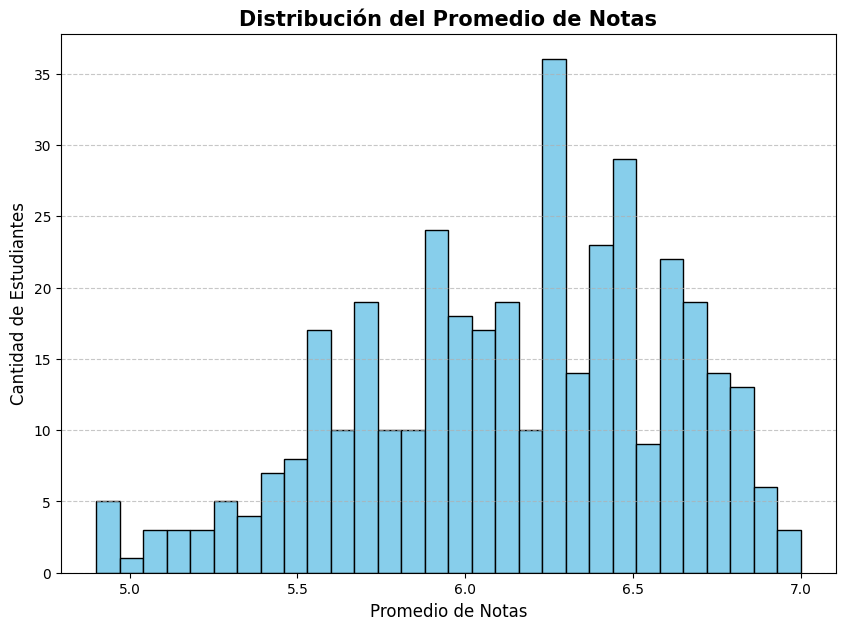

In [134]:
#VISUALIZACION DE LOS DATOS

# PROMEDIO NOTAS
#defino el tamaño del grafico y tomo la columna PROMEDIO_NOTAS para poder graficarla
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["PROMEDIO_NOTAS"], bins=30, color="skyblue", edgecolor="black")

# asigno los nombres a los ejes (x, y) junto con el nombre del gráfico
plt.title("Distribución del Promedio de Notas", fontsize=15, fontweight='bold')
plt.xlabel("Promedio de Notas", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

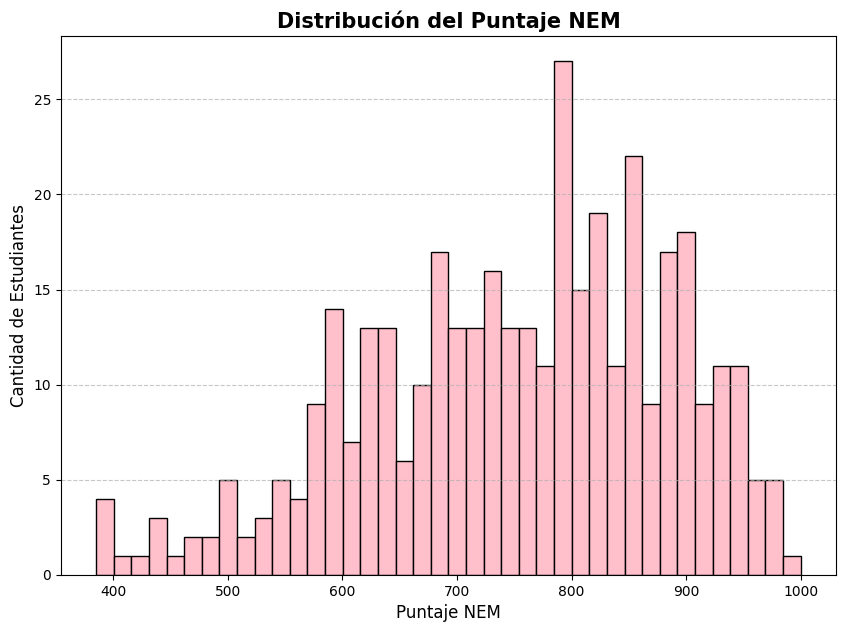

In [135]:
# PUNTAJE NEM
# defino el tamaño del grafico y tomo la columna deseada para trabajar
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["PTJE_NEM"], bins=40, color="pink", edgecolor="black")

plt.title("Distribución del Puntaje NEM", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje NEM", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

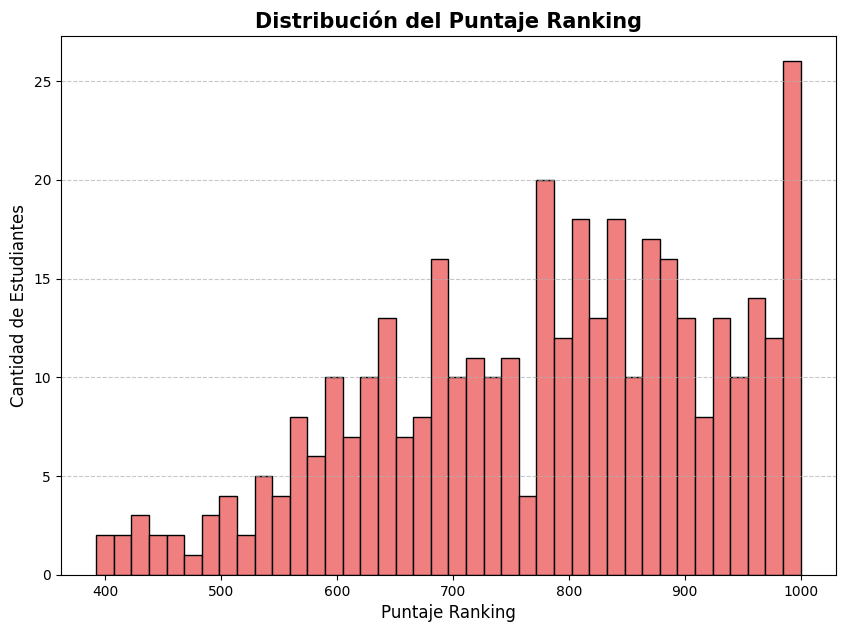

In [136]:
# PTJE_RANKING
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["PTJE_RANKING"], bins=40, color="lightcoral", edgecolor="black")
# le asigno los nombres a los ejes (x,y) y tambien al grafico
plt.title("Distribución del Puntaje Ranking", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje Ranking", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show() # se muestra el grafico

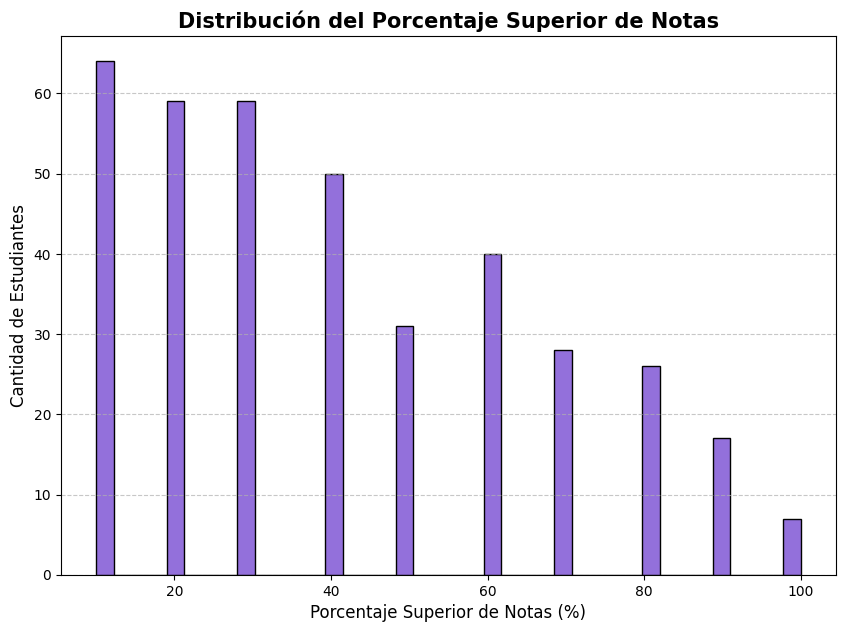

In [137]:
# PORC_SUP_NOTAS
# dimensiones del grafico
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["PORC_SUP_NOTAS"], bins=40, color="mediumpurple", edgecolor="black")
# nombre del grafico y de los ejes (x,y)
plt.title("Distribución del Porcentaje Superior de Notas", fontsize=15, fontweight="bold")
plt.xlabel("Porcentaje Superior de Notas (%)", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

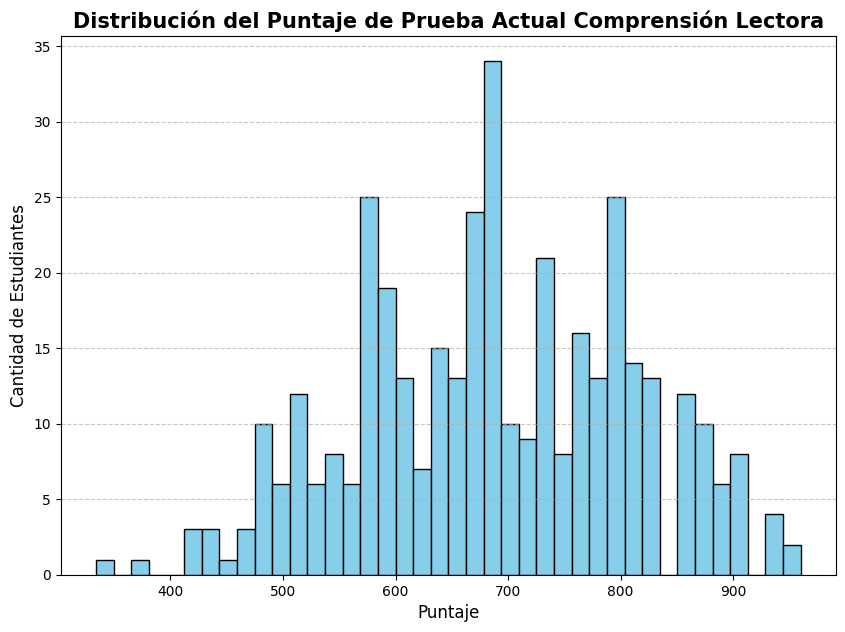

In [138]:
# CLEC_REG_ACTUAL

plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["CLEC_REG_ACTUAL"], bins=40, color="skyblue", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Actual Comprensión Lectora", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

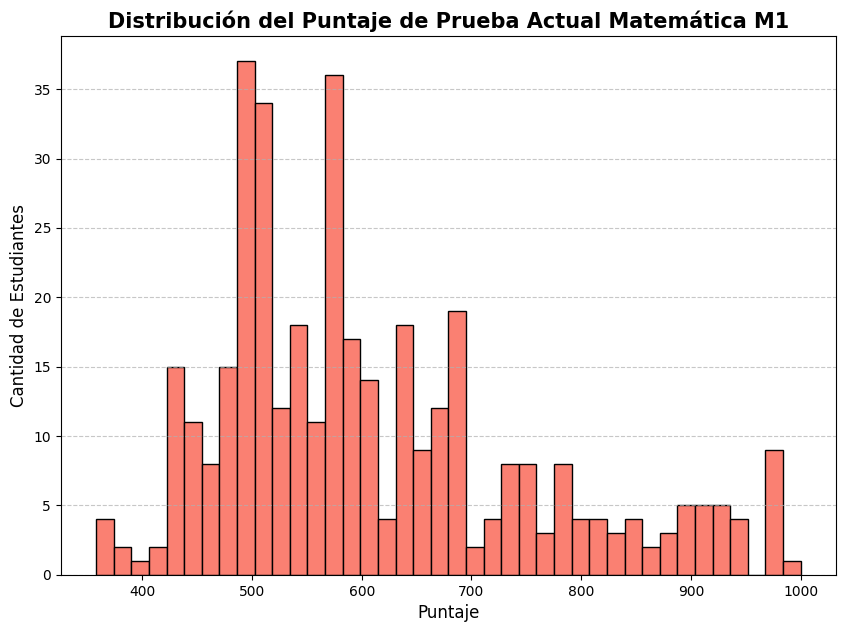

In [139]:
#MATE1_REG_ACTUAL
# (M1 actual)
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["MATE1_REG_ACTUAL"], bins=40, color="salmon", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Actual Matemática M1", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

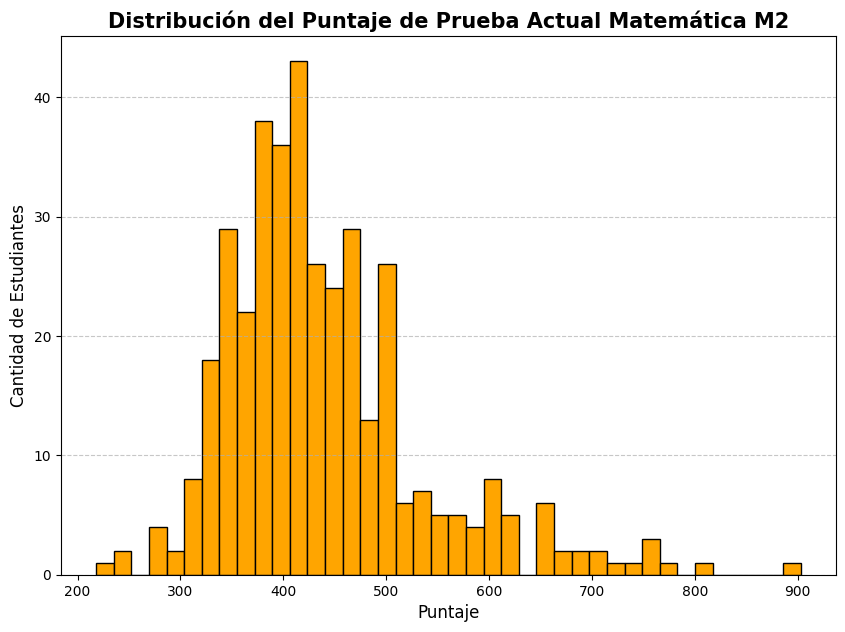

In [140]:
#MATE2_REG_ACTUAL
# (M2 actual)
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["MATE2_REG_ACTUAL"], bins=40, color="orange", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Actual Matemática M2", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

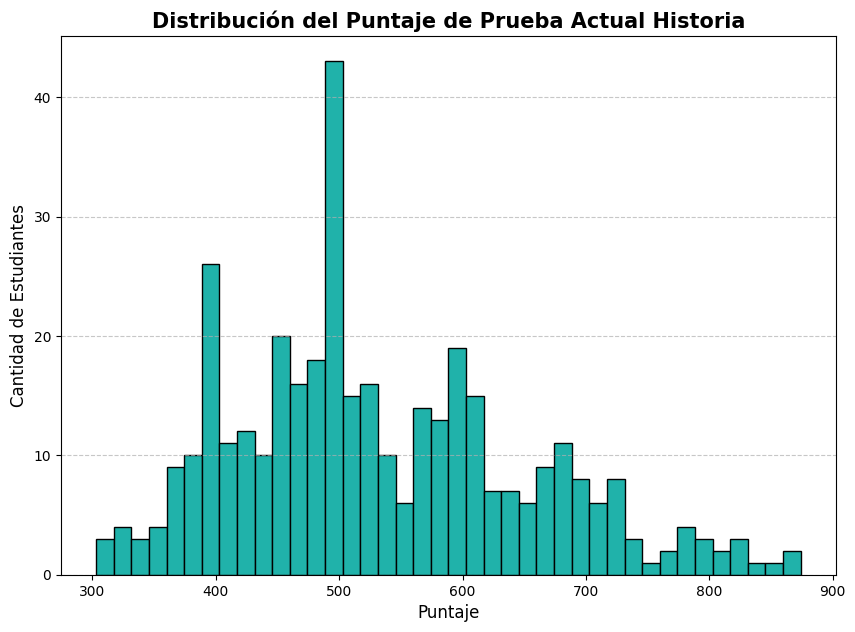

In [141]:
#HCSOC_REG_ACTUAL
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["HCSOC_REG_ACTUAL"], bins=40, color="lightseagreen", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Actual Historia", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

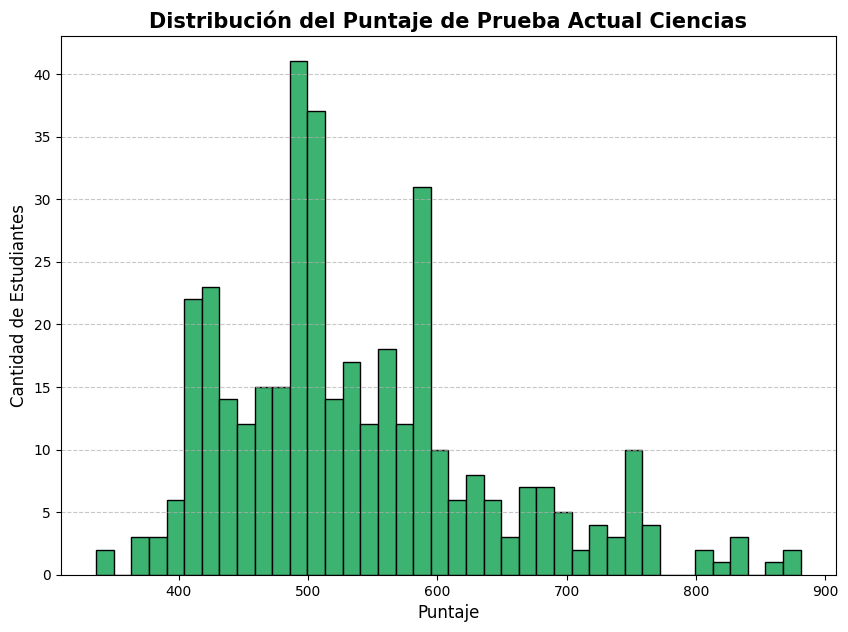

In [142]:
# CIEN_REG_ACTUAL
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["CIEN_REG_ACTUAL"].dropna(), bins=40, color="mediumseagreen", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Actual Ciencias", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

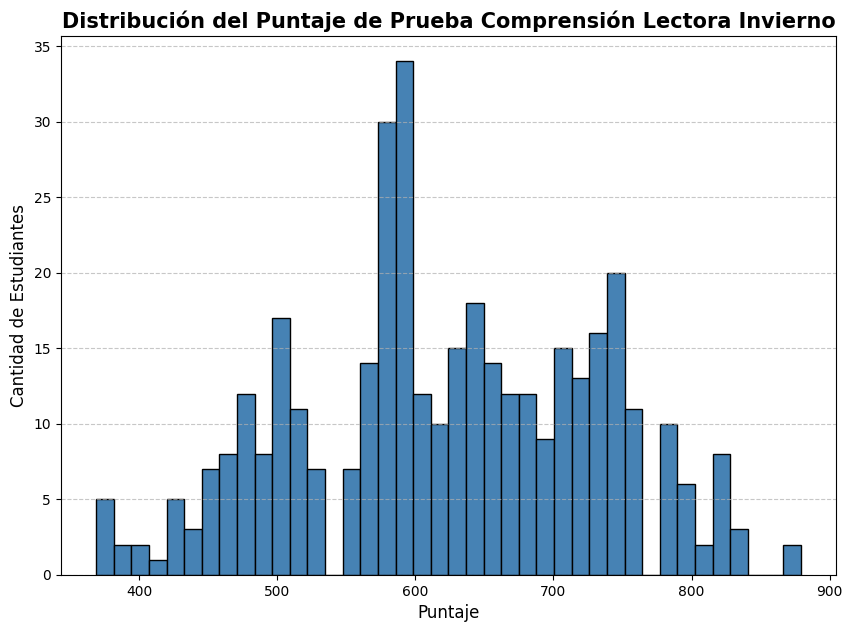

In [143]:
# CLEC_INV_ACTUAL

plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["CLEC_INV_ACTUAL"], bins=40, color="steelblue", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Comprensión Lectora Invierno", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

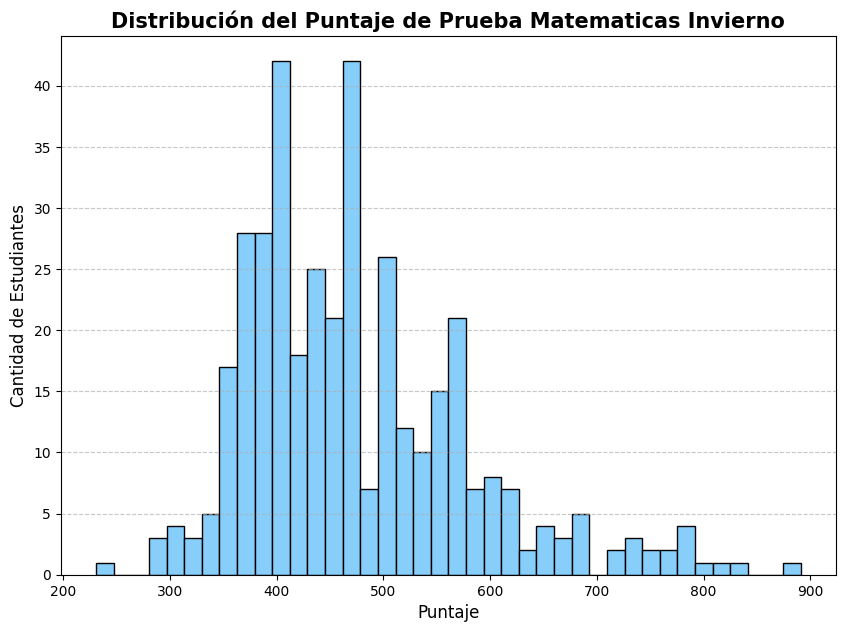

In [144]:
# MATE_INV_ACTUAL

plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["MATE_INV_ACTUAL"], bins=40, color="lightskyblue", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Matematicas Invierno", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

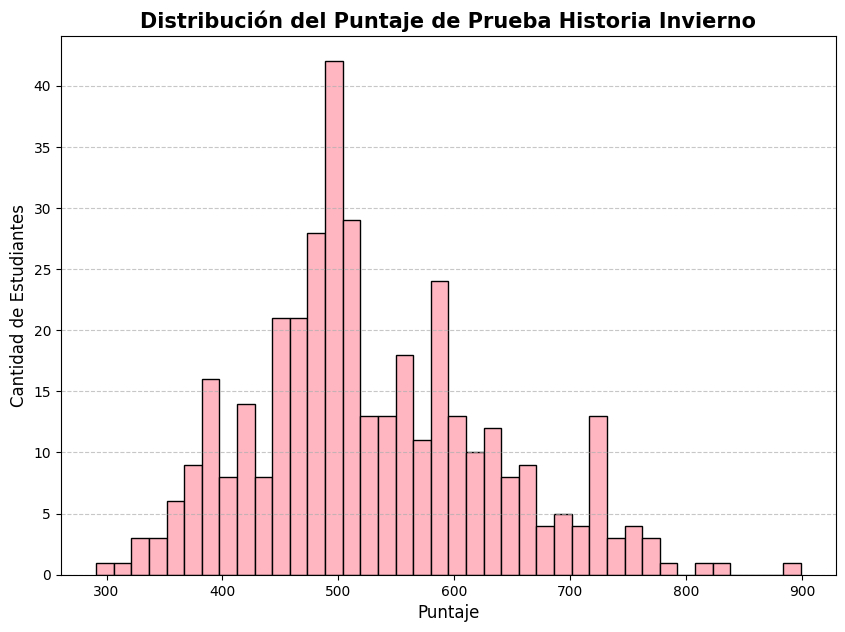

In [146]:
# HCSOC_INV_ACTUAL

plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["HCSOC_INV_ACTUAL"], bins=40, color="lightpink", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Historia Invierno", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

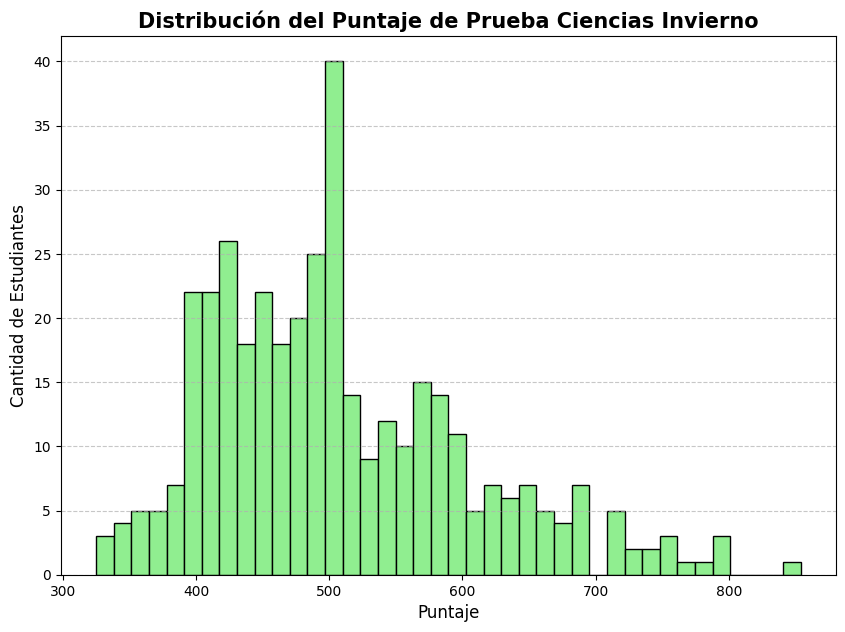

In [148]:
# CIEN_INV_ACTUAL

plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["CIEN_INV_ACTUAL"], bins=40, color="lightgreen", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Ciencias Invierno", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

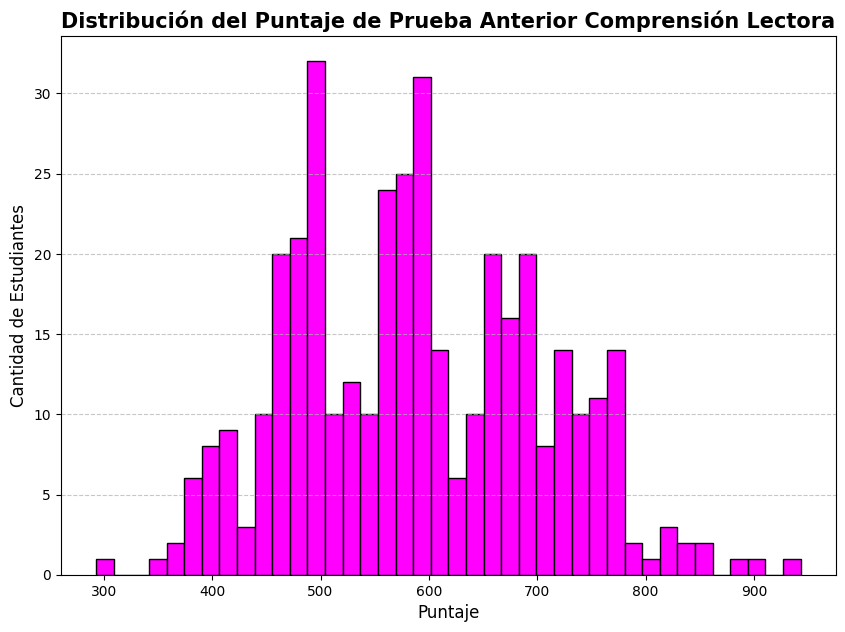

In [151]:
# CLEC_REG_ANTERIOR
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["CLEC_REG_ANTERIOR"], bins=40, color="magenta", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Anterior Comprensión Lectora", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

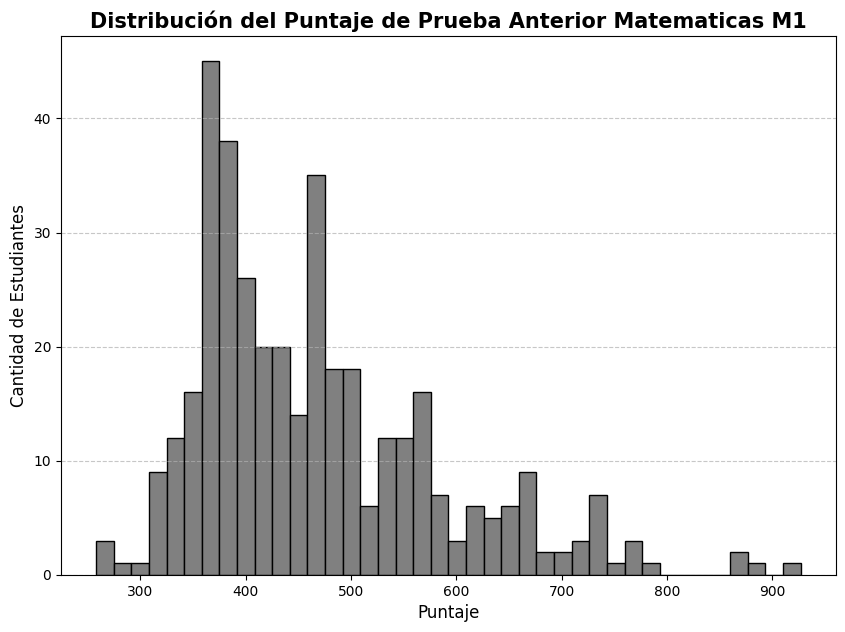

In [154]:
# MATE1_REG_ANTERIOR
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["MATE1_REG_ANTERIOR"], bins=40, color="gray", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Anterior Matematicas M1", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

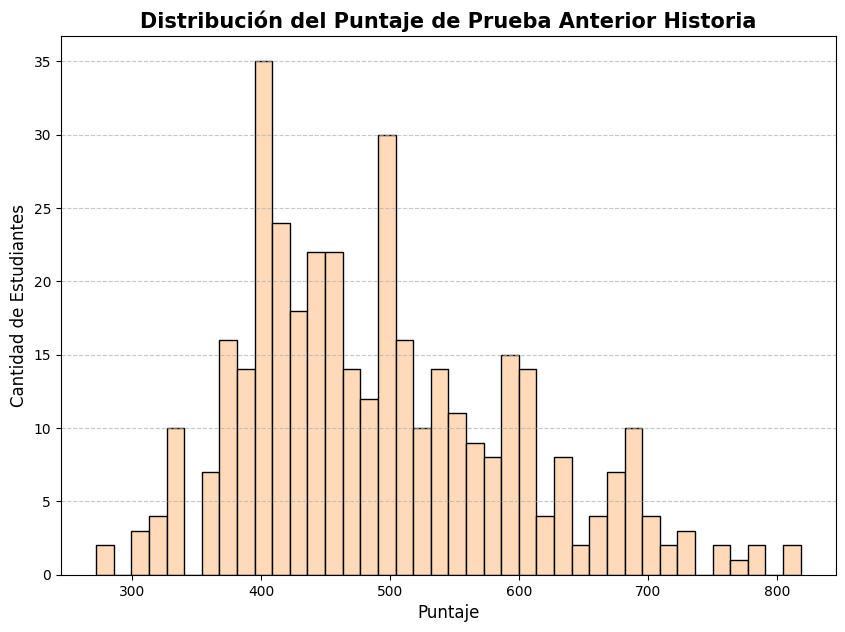

In [163]:
# HCSOC_REG_ANTERIOR
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["HCSOC_REG_ANTERIOR"], bins=40, color="peachpuff", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Anterior Historia", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

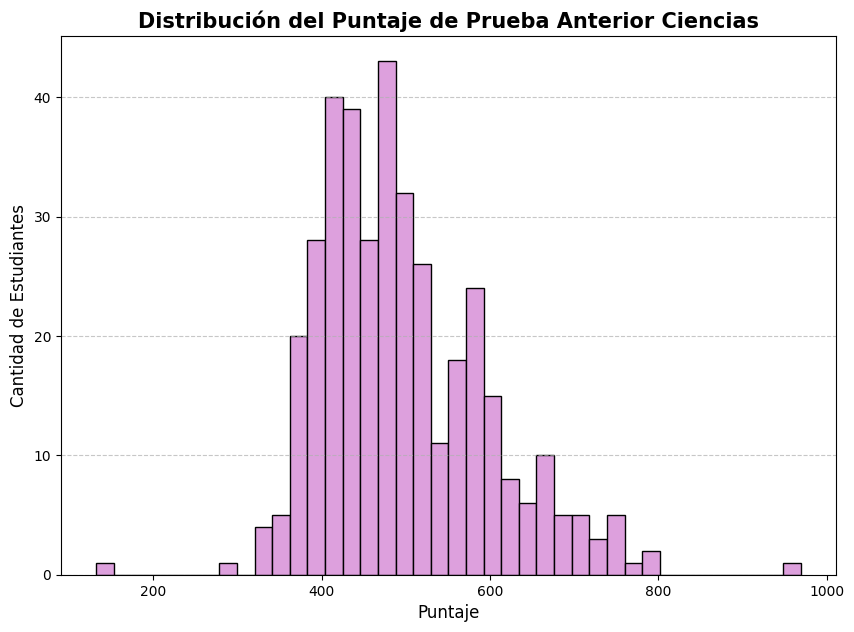

In [167]:
# CIEN_REG_ANTERIOR
plt.figure(figsize=(10, 7))
plt.hist(dataf_rendicion["CIEN_REG_ANTERIOR"], bins=40, color="plum", edgecolor="black")

plt.title("Distribución del Puntaje de Prueba Anterior Ciencias", fontsize=15, fontweight="bold")
plt.xlabel("Puntaje", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

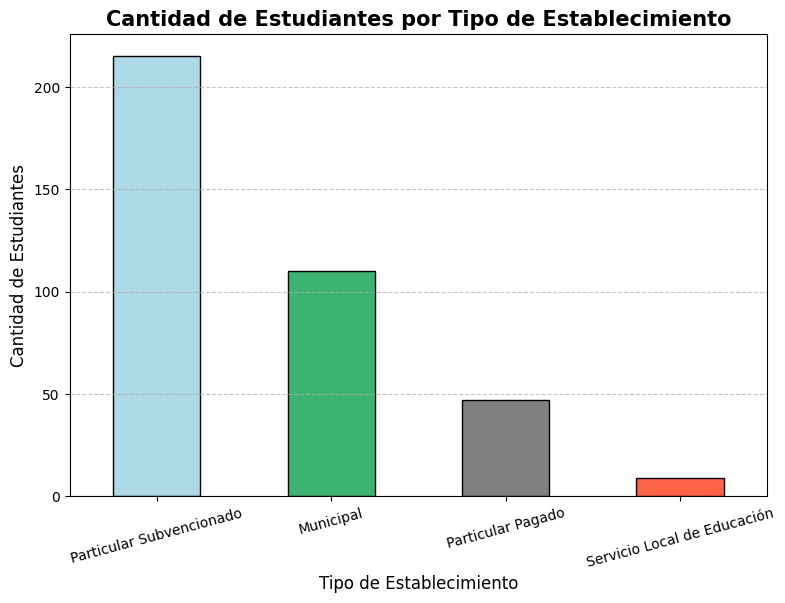

In [174]:
# GRUPO DE DEPENDENCIA

# hago un dict para poder cambiar el numero con el establecimiento que representa dicho num
mapa_dependencia = {1: "Particular Pagado", 2: "Particular Subvencionado", 
    3: "Municipal", 4: "Servicio Local de Educación"}
# creo una nueva columnna con el tipo de establecimiento
dataf_rendicion["Dependencia"] = dataf_rendicion["GRUPO_DEPENDENCIA"].map(mapa_dependencia)
conteo = dataf_rendicion["Dependencia"].value_counts()
# defino el tamaño del grafico
plt.figure(figsize=(9,6))
conteo.plot(kind="bar", color=["lightblue", "mediumseagreen", "gray", "tomato"], edgecolor="black")
# le asignamos los nombre a los ejes del grafico y al nombre de este tambien
plt.title("Cantidad de Estudiantes por Tipo de Establecimiento", fontsize=15, fontweight="bold")
plt.xlabel("Tipo de Establecimiento", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

------------------------------------------------------------------------------------------------------------------------